In [1]:
# Блок 1: Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score
import re
import string
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Установка дополнительных библиотек для русского языка
!pip -q install pymorphy2 nltk
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Блок 2: Загрузка и анализ данных
# Загружаем датасет с резюме
df = pd.read_csv('resumes_cleaned.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df[['ФИО', 'Желаемая должность', 'Ключевые навыки']].head())

print("\nСтатистика по желаемым должностям:")
job_counts = df['Желаемая должность'].value_counts()
print(job_counts.head(20))  # Покажем топ-20

print(f"\nВсего уникальных должностей: {len(job_counts)}")

Размер датасета: (235, 14)

Первые 5 строк:
        ФИО         Желаемая должность  \
0  Кандидат           Senior developer   
1  Кандидат           Senior Developer   
2  Кандидат      .Net Senior developer   
3  Кандидат  Senior Software Developer   
4  Кандидат       Senior PHP Developer   

                                     Ключевые навыки  
0  ATM, C/C++, device driver, DVB, embedded, Kern...  
1  PHP, MySQL, JavaScript, jQuery, HTML, CSS, ООП...  
2  SQL, Git, MS SQL, С#, MS SQL Server, SOLID, LI...  
3  C/C++, Java, Unix, Java Servlets, Linux, Git, ...  
4  PHP, Golang, JavaScript, HTML, MySQL, jQuery, ...  

Статистика по желаемым должностям:
Желаемая должность
Junior Java Developer        8
Frontend-разработчик         5
Junior Frontend Developer    4
Senior Frontend Developer    4
Senior Java developer        3
.Net Developer               3
Python Developer             3
Frontend developer           3
Junior developer             3
Junior Developer             3
Java Dev

In [3]:
# Блок 3: Функция для объединения похожих профессий
def generalize_job_title(job_title):
    """
    Объединяет похожие должности в обобщенные категории
    Убирает уровни (Junior, Senior, Lead) и объединяет по специализациям
    """
    if pd.isna(job_title):
        return "Other"

    job_lower = str(job_title).lower()

    # Удаляем уровни
    job_lower = re.sub(r'\b(junior|senior|middle|lead|principal|chief|head|главный|ведущий|старший|младший)\b', '', job_lower)
    job_lower = re.sub(r'\s+', ' ', job_lower).strip()

    # Frontend разработка
    if any(word in job_lower for word in ['frontend', 'front-end', 'react', 'angular', 'vue', 'javascript', 'js', 'ui', 'ux']):
        return 'Frontend Developer'

    # Backend разработка
    elif any(word in job_lower for word in ['backend', 'back-end', 'server', 'api', 'rest', 'graphql']):
        return 'Backend Developer'

    # Fullstack разработка
    elif any(word in job_lower for word in ['fullstack', 'full-stack', 'full stack']):
        return 'Fullstack Developer'

    # Data Science / ML
    elif any(word in job_lower for word in ['data scientist', 'machine learning', 'ml', 'ai', 'data science', 'data analyst']):
        return 'Data Scientist'

    # Python разработка
    elif any(word in job_lower for word in ['python', 'django', 'flask', 'fastapi']):
        return 'Python Developer'

    # Java разработка
    elif any(word in job_lower for word in ['java', 'spring', 'kotlin']):
        return 'Java Developer'

    # Mobile разработка
    elif any(word in job_lower for word in ['android', 'ios', 'mobile', 'react native', 'flutter']):
        return 'Mobile Developer'

    # DevOps / SysAdmin
    elif any(word in job_lower for word in ['devops', 'sysadmin', 'system administrator', 'sre', 'site reliability']):
        return 'DevOps/SysAdmin'

    # Project/Product Management
    elif any(word in job_lower for word in ['project manager', 'product manager', 'pm', 'менеджер проектов', 'продакт']):
        return 'Project/Product Manager'

    # QA/Testing
    elif any(word in job_lower for word in ['qa', 'quality assurance', 'тестировщик', 'test', 'testing']):
        return 'QA Engineer'

    # 1C разработка
    elif any(word in job_lower for word in ['1c', '1с', '1c программист']):
        return '1C Developer'

    # C++/C# разработка
    elif any(word in job_lower for word in ['c++', 'c#', '.net', 'cpp', 'c sharp']):
        return 'C++/C# Developer'

    # Web разработка (общее)
    elif any(word in job_lower for word in ['web', 'web developer', 'веб-разработчик']):
        return 'Web Developer'

    # Software Engineer (общее)
    elif any(word in job_lower for word in ['software', 'developer', 'разработчик', 'programmer', 'engineer']):
        return 'Software Developer'

    else:
        return 'Other'

In [4]:
# Блок 4: Применяем объединение профессий
print("\n" + "="*60)
print("ОБЪЕДИНЕНИЕ ПРОФЕССИЙ В ОБОБЩЕННЫЕ КАТЕГОРИИ")
print("="*60)

# Создаем новую колонку с обобщенными категориями
df['generalized_job'] = df['Желаемая должность'].apply(generalize_job_title)

# Анализируем результат
generalized_counts = df['generalized_job'].value_counts()
print("Распределение по обобщенным категориям:")
print(generalized_counts)

print(f"\nВсего обобщенных категорий: {len(generalized_counts)}")


ОБЪЕДИНЕНИЕ ПРОФЕССИЙ В ОБОБЩЕННЫЕ КАТЕГОРИИ
Распределение по обобщенным категориям:
generalized_job
Software Developer         52
Frontend Developer         44
Java Developer             39
Other                      24
Python Developer           14
C++/C# Developer           14
Mobile Developer           12
Backend Developer           9
Data Scientist              8
Fullstack Developer         6
Web Developer               5
Project/Product Manager     3
QA Engineer                 3
DevOps/SysAdmin             2
Name: count, dtype: int64

Всего обобщенных категорий: 14


In [5]:
# Блок 5: Выбираем категории для классификации
# Отберем категории с достаточным количеством записей
MIN_SAMPLES_PER_CLASS = 10  # Минимум для демонстрации
selected_categories = generalized_counts[generalized_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()

print(f"\nКатегории с ≥ {MIN_SAMPLES_PER_CLASS} записями:")
for i, category in enumerate(selected_categories, 1):
    count = generalized_counts[category]
    print(f"{i}. {category}: {count} записей")

# Фильтруем датасет по выбранным категориям
df_filtered = df[df['generalized_job'].isin(selected_categories)].copy()

print(f"\nРазмер отфильтрованного датасета: {df_filtered.shape}")
print(f"Используется {len(selected_categories)} категорий из {len(generalized_counts)}")


Категории с ≥ 10 записями:
1. Software Developer: 52 записей
2. Frontend Developer: 44 записей
3. Java Developer: 39 записей
4. Other: 24 записей
5. Python Developer: 14 записей
6. C++/C# Developer: 14 записей
7. Mobile Developer: 12 записей

Размер отфильтрованного датасета: (199, 15)
Используется 7 категорий из 14


In [6]:
# Блок 6: Балансировка классов
print("\n" + "="*60)
print("БАЛАНСИРОВКА КЛАССОВ")
print("="*60)

# Определяем минимальное количество образцов для балансировки
min_samples = min(generalized_counts[selected_categories].min(), 30)

balanced_data = []
print("Балансировка классов:")
for category in selected_categories:
    category_data = df_filtered[df_filtered['generalized_job'] == category]
    if len(category_data) > min_samples:
        category_data = category_data.sample(min_samples, random_state=42)
    balanced_data.append(category_data)
    print(f"{category}: {len(category_data)} записей")

df_balanced = pd.concat(balanced_data)
print(f"\nИтоговый размер сбалансированного датасета: {df_balanced.shape}")


БАЛАНСИРОВКА КЛАССОВ
Балансировка классов:
Software Developer: 12 записей
Frontend Developer: 12 записей
Java Developer: 12 записей
Other: 12 записей
Python Developer: 12 записей
C++/C# Developer: 12 записей
Mobile Developer: 12 записей

Итоговый размер сбалансированного датасета: (84, 15)


In [7]:
# Блок 7: Анти-ликиха - маскирование чувствительной информации
def mask_sensitive_info(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Маскирование уровней и конкретных должностей
    levels = [
        r'\b(?:junior|senior|middle|lead|principal|chief|head)\b',
        r'\b(?:младший|старший|ведущий|главный)\b'
    ]

    for pattern in levels:
        text = re.sub(pattern, '[LEVEL]', text, flags=re.IGNORECASE)

    # Маскирование компаний
    companies = [
        r'\b(?:google|yandex|mail\.ru|microsoft|apple|amazon|facebook)\b',
        r'\b(?:сбербанк|тинькофф|втб|альфа-банк|газпром|лукойл)\b',
        r'\b(?:ozon|wildberries|avito|lamoda|dns|mvideo)\b',
        r'\b(?:jetbrains|kaspersky|abbyy|1с|1c)\b'
    ]

    for pattern in companies:
        text = re.sub(pattern, '[ORG]', text, flags=re.IGNORECASE)

    return text

# Применяем маскирование к текстовым полям
text_columns = ['Желаемая должность', 'Обязанности', 'Ключевые навыки', 'Обо мне']
for col in text_columns:
    if col in df_balanced.columns:
        df_balanced[f'masked_{col}'] = df_balanced[col].apply(mask_sensitive_info)

In [8]:
# Блок 8: Подготовка текстовых данных
# Объединяем все текстовые поля в один признак
df_balanced['combined_text'] = ''
text_cols_to_use = [f'masked_{col}' for col in text_columns if f'masked_{col}' in df_balanced.columns]

for col in text_cols_to_use:
    df_balanced['combined_text'] += ' ' + df_balanced[col].fillna('')

# Функция для предобработки русского текста
def preprocess_russian_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Удаление пунктуации и цифр
    text = re.sub(f'[{string.punctuation}0-9]', ' ', text)

    # Удаление лишних пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    # Удаление стоп-слов
    russian_stopwords = set(stopwords.words('russian'))
    words = text.split()
    words = [word for word in words if word not in russian_stopwords and len(word) > 2]

    return ' '.join(words)

# Применяем предобработку
df_balanced['processed_text'] = df_balanced['combined_text'].apply(preprocess_russian_text)


СОЗДАНИЕ ДОПОЛНИТЕЛЬНЫХ ПРИЗНАКОВ
Статистика дополнительных признаков:
Word Count: mean=142.4, std=121.7
Tech Keywords Count: mean=8.8, std=7.4


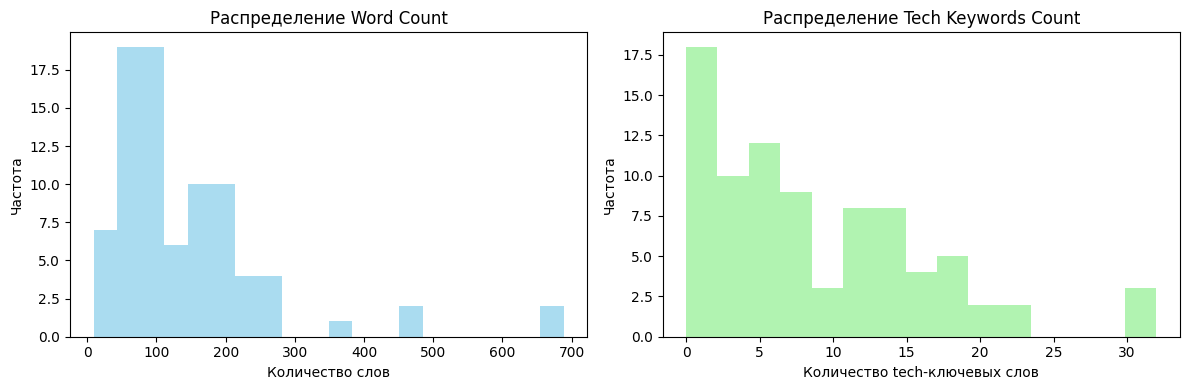

In [9]:
# Блок 8.1: Создание дополнительных признаков
print("\n" + "="*60)
print("СОЗДАНИЕ ДОПОЛНИТЕЛЬНЫХ ПРИЗНАКОВ")
print("="*60)

def extract_additional_features(text):
    """Извлекает дополнительные признаки из текста резюме"""
    if pd.isna(text):
        return 0, 0

    text_str = str(text)

    # 1. Word Count - количество слов
    word_count = len(text_str.split())

    # 2. Tech Stack Count - количество упоминаний технологий
    tech_keywords = [
        'python', 'java', 'javascript', 'react', 'angular', 'vue', 'sql', 'nosql',
        'docker', 'kubernetes', 'aws', 'azure', 'git', 'linux', 'html', 'css',
        'c++', 'c#', '.net', 'php', 'ruby', 'go', 'rust', 'swift', 'kotlin',
        'django', 'flask', 'spring', 'node', 'express', 'mongodb', 'postgresql',
        'mysql', 'redis', 'elasticsearch', 'kafka', 'rabbitmq'
    ]

    tech_count = 0
    for tech in tech_keywords:
        tech_count += len(re.findall(r'\b' + re.escape(tech) + r'\b', text_str.lower()))

    return word_count, tech_count

# Применяем извлечение признаков
word_counts = []
tech_counts = []

for text in df_balanced['combined_text']:
    wc, tc = extract_additional_features(text)
    word_counts.append(wc)
    tech_counts.append(tc)

df_balanced['word_count'] = word_counts
df_balanced['tech_keywords_count'] = tech_counts

print("Статистика дополнительных признаков:")
print(f"Word Count: mean={np.mean(word_counts):.1f}, std={np.std(word_counts):.1f}")
print(f"Tech Keywords Count: mean={np.mean(tech_counts):.1f}, std={np.std(tech_counts):.1f}")

# Визуализация дополнительных признаков
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_balanced['word_count'], bins=20, alpha=0.7, color='skyblue')
axes[0].set_title('Распределение Word Count')
axes[0].set_xlabel('Количество слов')
axes[0].set_ylabel('Частота')

axes[1].hist(df_balanced['tech_keywords_count'], bins=15, alpha=0.7, color='lightgreen')
axes[1].set_title('Распределение Tech Keywords Count')
axes[1].set_xlabel('Количество tech-ключевых слов')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

In [10]:
# Блок 8.2: Визуализация анти-ликиха с выделением
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ АНТИ-ЛИКИХА С ВЫДЕЛЕНИЕМ ЗАМЕН")
print("="*60)

def mask_with_highlight(text):
    """Маскирует чувствительную информацию с возвратом текста для визуализации"""
    if pd.isna(text):
        return text, text

    original = str(text)
    masked = original

    # Маскирование с сохранением информации о заменах
    replacements = []

    # Уровни
    level_matches = list(re.finditer(
        r'\b(junior|senior|middle|lead|principal|chief|head|младший|старший|ведущий|главный)\b',
        masked, re.IGNORECASE
    ))
    for match in reversed(level_matches):
        start, end = match.span()
        replacements.append((start, end, '[LEVEL]', masked[start:end]))
        masked = masked[:start] + '[LEVEL]' + masked[end:]

    # Компании
    company_matches = list(re.finditer(
        r'\b(google|yandex|mail\.ru|microsoft|apple|amazon|facebook|сбербанк|тинькофф|втб|альфа-банк|газпром|лукойл|ozon|wildberries|avito|lamoda|jetbrains|kaspersky|abbyy|1с|1c)\b',
        masked, re.IGNORECASE
    ))
    for match in reversed(company_matches):
        start, end = match.span()
        replacements.append((start, end, '[ORG]', masked[start:end]))
        masked = masked[:start] + '[ORG]' + masked[end:]

    # Создаем текст с подсветкой для визуализации
    highlighted = original
    for start, end, replacement, original_text in sorted(replacements, key=lambda x: x[0], reverse=True):
        highlighted = highlighted[:start] + f'[{replacement}]' + highlighted[end:]

    return masked, highlighted

# Демонстрация анти-ликиха
sample_texts = df_balanced['Желаемая должность'].dropna().head(3).tolist()

for i, text in enumerate(sample_texts):
    masked, highlighted = mask_with_highlight(text)
    print(f"\nПример {i+1}:")
    print(f"Оригинал: {text}")
    print(f"После маскирования: {masked}")
    print(f"Визуализация замен: {highlighted}")


ВИЗУАЛИЗАЦИЯ АНТИ-ЛИКИХА С ВЫДЕЛЕНИЕМ ЗАМЕН

Пример 1:
Оригинал: Junior разработчик
После маскирования: [LEVEL] разработчик
Визуализация замен: [[LEVEL]] разработчик

Пример 2:
Оригинал: Senior or Middle Developer
После маскирования: [LEVEL] or [LEVEL] Developer
Визуализация замен: [[LEVEL]] or [[LEVEL]] Developer

Пример 3:
Оригинал: С++ разработчик компьютерной графики
После маскирования: С++ разработчик компьютерной графики
Визуализация замен: С++ разработчик компьютерной графики


In [11]:
# Блок 9: Векторизация текста
# Кодируем метки (обобщенные категории)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_balanced['generalized_job'])

print("Закодированные метки (обобщенные категории):")
for i, category in enumerate(label_encoder.classes_):
    print(f"{category}: {i}")

# Разделяем на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['processed_text'], y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nРазмер тренировочной выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")


Закодированные метки (обобщенные категории):
C++/C# Developer: 0
Frontend Developer: 1
Java Developer: 2
Mobile Developer: 3
Other: 4
Python Developer: 5
Software Developer: 6

Размер тренировочной выборки: 67
Размер тестовой выборки: 17


In [12]:
# Блок 10: Создание векторизаторов
# TF-IDF на словах (1-2 граммы)
tfidf_word_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words=stopwords.words('russian')
)

# TF-IDF на символах (3-5 грамм)
tfidf_char_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(3, 5),
    analyzer='char'
)

# Count Vectorizer
count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words=stopwords.words('russian')
)

In [13]:
# Блок 11: Базовые модели машинного обучения
models = {
    'SVM': SVC(probability=True, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'NaiveBayes': MultinomialNB()
}


In [14]:
# Функция для обучения и оценки моделей
def evaluate_model(model, X_train_vec, X_test_vec, y_train, y_test, model_name):
    print(f"\n=== {model_name} ===")

    # Обучение модели
    model.fit(X_train_vec, y_train)

    # Предсказания
    y_pred = model.predict(X_test_vec)

    # Для моделей, поддерживающих predict_proba
    try:
        y_pred_proba = model.predict_proba(X_test_vec)
    except:
        y_pred_proba = None

    # Метрики
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Macro-F1: {macro_f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    return model, y_pred, y_pred_proba, macro_f1

In [15]:
# Блок 12: Обучение и оценка моделей с разными векторизаторами
results = {}

# TF-IDF слова
print("="*50)
print("TF-IDF WORDS (1-2 grams)")
print("="*50)
X_train_tfidf_word = tfidf_word_vectorizer.fit_transform(X_train)
X_test_tfidf_word = tfidf_word_vectorizer.transform(X_test)

for model_name, model in models.items():
    trained_model, y_pred, y_pred_proba, f1_score_val = evaluate_model(
        model, X_train_tfidf_word, X_test_tfidf_word, y_train, y_test, f"{model_name} + TF-IDF Words"
    )
    results[f"{model_name} + TF-IDF Words"] = {
        'model': trained_model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'f1_score': f1_score_val
    }

# TF-IDF символы
print("\n" + "="*50)
print("TF-IDF CHARS (3-5 grams)")
print("="*50)
X_train_tfidf_char = tfidf_char_vectorizer.fit_transform(X_train)
X_test_tfidf_char = tfidf_char_vectorizer.transform(X_test)

for model_name, model in models.items():
    trained_model, y_pred, y_pred_proba, f1_score_val = evaluate_model(
        model, X_train_tfidf_char, X_test_tfidf_char, y_train, y_test, f"{model_name} + TF-IDF Chars"
    )
    results[f"{model_name} + TF-IDF Chars"] = {
        'model': trained_model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'f1_score': f1_score_val
    }

# Count Vectorizer
print("\n" + "="*50)
print("COUNT VECTORIZER")
print("="*50)
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

for model_name, model in models.items():
    trained_model, y_pred, y_pred_proba, f1_score_val = evaluate_model(
        model, X_train_count, X_test_count, y_train, y_test, f"{model_name} + Count Vectorizer"
    )
    results[f"{model_name} + Count Vectorizer"] = {
        'model': trained_model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'f1_score': f1_score_val
    }

TF-IDF WORDS (1-2 grams)

=== SVM + TF-IDF Words ===
Macro-F1: 0.4626

Classification Report:
                    precision    recall  f1-score   support

  C++/C# Developer       0.33      0.50      0.40         2
Frontend Developer       0.40      1.00      0.57         2
    Java Developer       0.50      1.00      0.67         2
  Mobile Developer       1.00      0.67      0.80         3
             Other       0.00      0.00      0.00         3
  Python Developer       0.67      1.00      0.80         2
Software Developer       0.00      0.00      0.00         3

          accuracy                           0.53        17
         macro avg       0.41      0.60      0.46        17
      weighted avg       0.40      0.53      0.43        17


=== RandomForest + TF-IDF Words ===
Macro-F1: 0.4619

Classification Report:
                    precision    recall  f1-score   support

  C++/C# Developer       0.33      0.50      0.40         2
Frontend Developer       1.00      0.50     

In [16]:
# Блок 12.1: Модели с дополнительными признаками
print("\n" + "="*60)
print("МОДЕЛИ С ДОПОЛНИТЕЛЬНЫМИ ПРИЗНАКАМИ")
print("="*60)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Подготовка данных с дополнительными признаками
X_with_features = df_balanced[['processed_text', 'word_count', 'tech_keywords_count']]
y_with_features = y  # те же метки

X_train_feat, X_test_feat, y_train_feat, y_test_feat = train_test_split(
    X_with_features, y_with_features, test_size=0.2, random_state=42, stratify=y_with_features
)

# Создаем отдельные препроцессоры для разных типов моделей
def create_preprocessor(for_naive_bayes=False):
    """Создает препроцессор в зависимости от типа модели"""
    if for_naive_bayes:
        # Для NaiveBayes используем MinMaxScaler (не создает отрицательных значений)
        return ColumnTransformer(
            transformers=[
                ('text', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                       stop_words=stopwords.words('russian')), 'processed_text'),
                ('numeric', MinMaxScaler(), ['word_count', 'tech_keywords_count'])
            ]
        )
    else:
        # Для других моделей используем StandardScaler
        return ColumnTransformer(
            transformers=[
                ('text', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                       stop_words=stopwords.words('russian')), 'processed_text'),
                ('numeric', StandardScaler(), ['word_count', 'tech_keywords_count'])
            ]
        )

results_with_features = {}

for model_name, model in models.items():
    # Для NaiveBayes используем специальный препроцессор
    if model_name == 'NaiveBayes':
        preprocessor = create_preprocessor(for_naive_bayes=True)
    else:
        preprocessor = create_preprocessor(for_naive_bayes=False)

    # Создаем pipeline с препроцессором и моделью
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    try:
        # Обучаем на данных с дополнительными признаками
        pipeline.fit(X_train_feat, y_train_feat)
        y_pred_feat = pipeline.predict(X_test_feat)

        # Для моделей с вероятностями
        try:
            y_pred_proba_feat = pipeline.predict_proba(X_test_feat)
        except:
            y_pred_proba_feat = None

        macro_f1_feat = f1_score(y_test_feat, y_pred_feat, average='macro')

        print(f"\n{model_name} с дополнительными признаками:")
        print(f"Macro-F1: {macro_f1_feat:.4f}")

        results_with_features[f"{model_name} + Features"] = {
            'model': pipeline,
            'predictions': y_pred_feat,
            'probabilities': y_pred_proba_feat,
            'f1_score': macro_f1_feat
        }

    except Exception as e:
        print(f"Ошибка при обучении {model_name} с дополнительными признаками: {e}")
        # В случае ошибки, используем только текстовые признаки для этой модели
        print(f"Используем только текстовые признаки для {model_name}")

        # Простой пайплайн только с текстом
        text_pipeline = Pipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                    stop_words=stopwords.words('russian'))),
            ('classifier', model)
        ])

        text_pipeline.fit(X_train_feat['processed_text'], y_train_feat)
        y_pred_text = text_pipeline.predict(X_test_feat['processed_text'])

        try:
            y_pred_proba_text = text_pipeline.predict_proba(X_test_feat['processed_text'])
        except:
            y_pred_proba_text = None

        macro_f1_text = f1_score(y_test_feat, y_pred_text, average='macro')

        print(f"{model_name} (только текст): Macro-F1: {macro_f1_text:.4f}")

        results_with_features[f"{model_name} + Features"] = {
            'model': text_pipeline,
            'predictions': y_pred_text,
            'probabilities': y_pred_proba_text,
            'f1_score': macro_f1_text
        }



МОДЕЛИ С ДОПОЛНИТЕЛЬНЫМИ ПРИЗНАКАМИ

SVM с дополнительными признаками:
Macro-F1: 0.4524

RandomForest с дополнительными признаками:
Macro-F1: 0.6405

LogisticRegression с дополнительными признаками:
Macro-F1: 0.5796

NaiveBayes с дополнительными признаками:
Macro-F1: 0.4921


In [17]:
# Блок 12.2: Сравнение моделей с признаками и без
print("\n" + "="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ С ПРИЗНАКАМИ И БЕЗ")
print("="*60)

# Объединяем все результаты
all_results = {**results, **results_with_features}

comparison_data = []
for model_name, result in all_results.items():
    comparison_data.append({
        'Model': model_name,
        'Macro-F1': result['f1_score'],
        'Features': 'With Features' if 'Features' in model_name else 'Text Only'
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Macro-F1', ascending=False)

print("Сравнительная таблица:")
print(comparison_df)


СРАВНЕНИЕ МОДЕЛЕЙ С ПРИЗНАКАМИ И БЕЗ
Сравнительная таблица:
                                    Model  Macro-F1       Features
5             RandomForest + TF-IDF Chars  0.666667      Text Only
13                RandomForest + Features  0.640476  With Features
6       LogisticRegression + TF-IDF Chars  0.638095      Text Only
4                      SVM + TF-IDF Chars  0.633333      Text Only
9         RandomForest + Count Vectorizer  0.582684      Text Only
14          LogisticRegression + Features  0.579592  With Features
10  LogisticRegression + Count Vectorizer  0.576190      Text Only
7               NaiveBayes + TF-IDF Chars  0.542857      Text Only
11          NaiveBayes + Count Vectorizer  0.529252      Text Only
3               NaiveBayes + TF-IDF Words  0.529252      Text Only
8                  SVM + Count Vectorizer  0.523810      Text Only
15                  NaiveBayes + Features  0.492063  With Features
2       LogisticRegression + TF-IDF Words  0.485714      Text Only
0

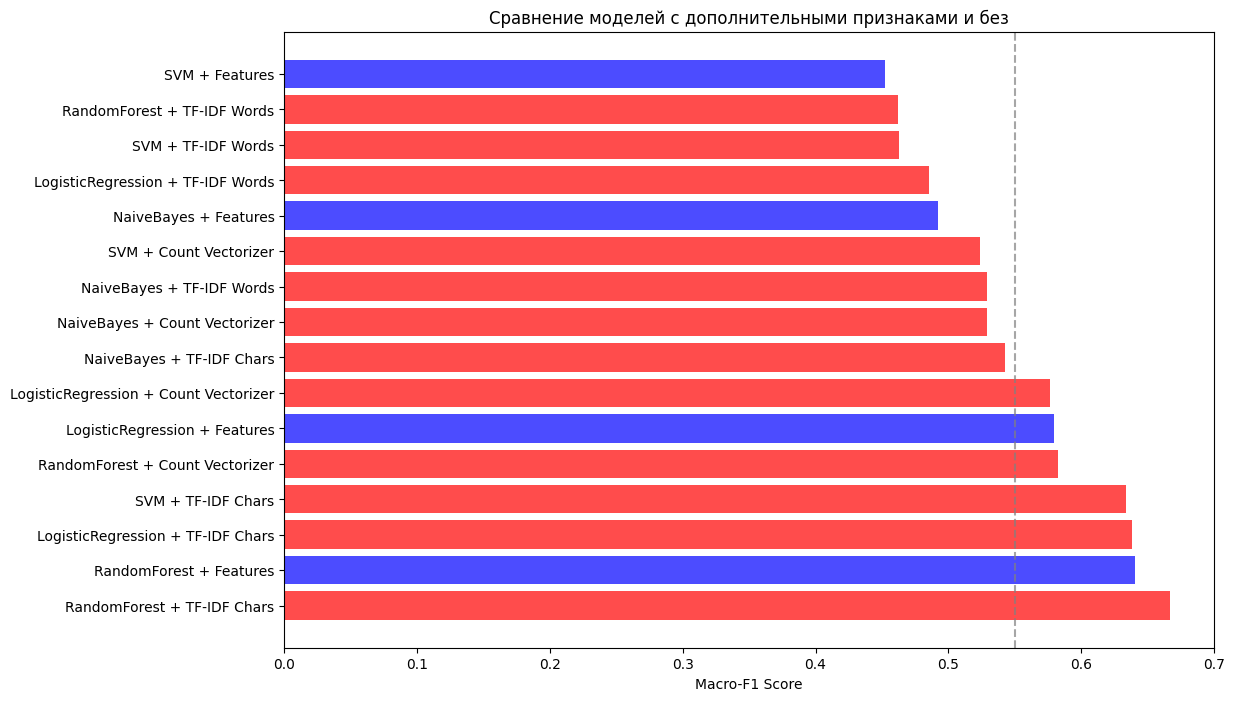

In [18]:
# Визуализация сравнения
plt.figure(figsize=(12, 8))
colors = ['red' if feat == 'Text Only' else 'blue' for feat in comparison_df['Features']]
bars = plt.barh(comparison_df['Model'], comparison_df['Macro-F1'], color=colors, alpha=0.7)
plt.xlabel('Macro-F1 Score')
plt.title('Сравнение моделей с дополнительными признаками и без')
plt.axvline(x=comparison_df['Macro-F1'].mean(), color='gray', linestyle='--', alpha=0.7)

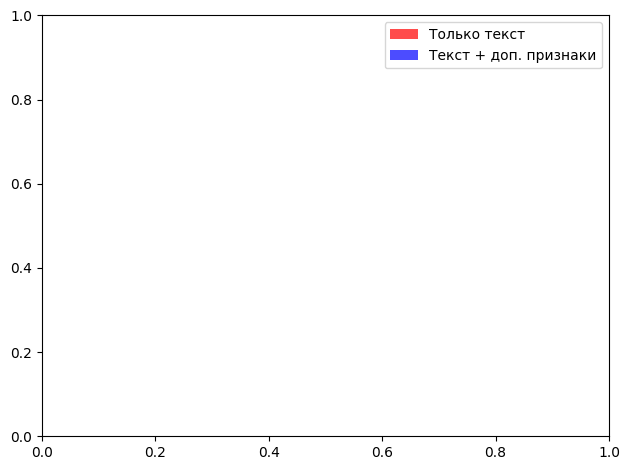

In [19]:
# Добавляем легенду
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Только текст'),
    Patch(facecolor='blue', alpha=0.7, label='Текст + доп. признаки')
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [20]:
# Блок 12.3: Анализ улучшения от дополнительных признаков
print("\nАНАЛИЗ УЛУЧШЕНИЯ ОТ ДОПОЛНИТЕЛЬНЫХ ПРИЗНАКОВ:")
basic_avg = comparison_df[comparison_df['Features'] == 'Text Only']['Macro-F1'].mean()
feature_avg = comparison_df[comparison_df['Features'] == 'With Features']['Macro-F1'].mean()
improvement = ((feature_avg - basic_avg) / basic_avg) * 100
print(f"Среднее улучшение: {improvement:+.1f}%")


АНАЛИЗ УЛУЧШЕНИЯ ОТ ДОПОЛНИТЕЛЬНЫХ ПРИЗНАКОВ:
Среднее улучшение: -2.1%


In [21]:
# Блок 13: Сравнение результатов и визуализация
print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ БАЗОВЫХ МОДЕЛЕЙ")
print("="*60)

f1_scores = {name: result['f1_score'] for name, result in results.items()}
sorted_scores = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)

print("Модели отсортированы по Macro-F1:")
for i, (model_name, score) in enumerate(sorted_scores, 1):
    print(f"{i:2d}. {model_name}: {score:.4f}")


СРАВНЕНИЕ РЕЗУЛЬТАТОВ БАЗОВЫХ МОДЕЛЕЙ
Модели отсортированы по Macro-F1:
 1. RandomForest + TF-IDF Chars: 0.6667
 2. LogisticRegression + TF-IDF Chars: 0.6381
 3. SVM + TF-IDF Chars: 0.6333
 4. RandomForest + Count Vectorizer: 0.5827
 5. LogisticRegression + Count Vectorizer: 0.5762
 6. NaiveBayes + TF-IDF Chars: 0.5429
 7. NaiveBayes + TF-IDF Words: 0.5293
 8. NaiveBayes + Count Vectorizer: 0.5293
 9. SVM + Count Vectorizer: 0.5238
10. LogisticRegression + TF-IDF Words: 0.4857
11. SVM + TF-IDF Words: 0.4626
12. RandomForest + TF-IDF Words: 0.4619


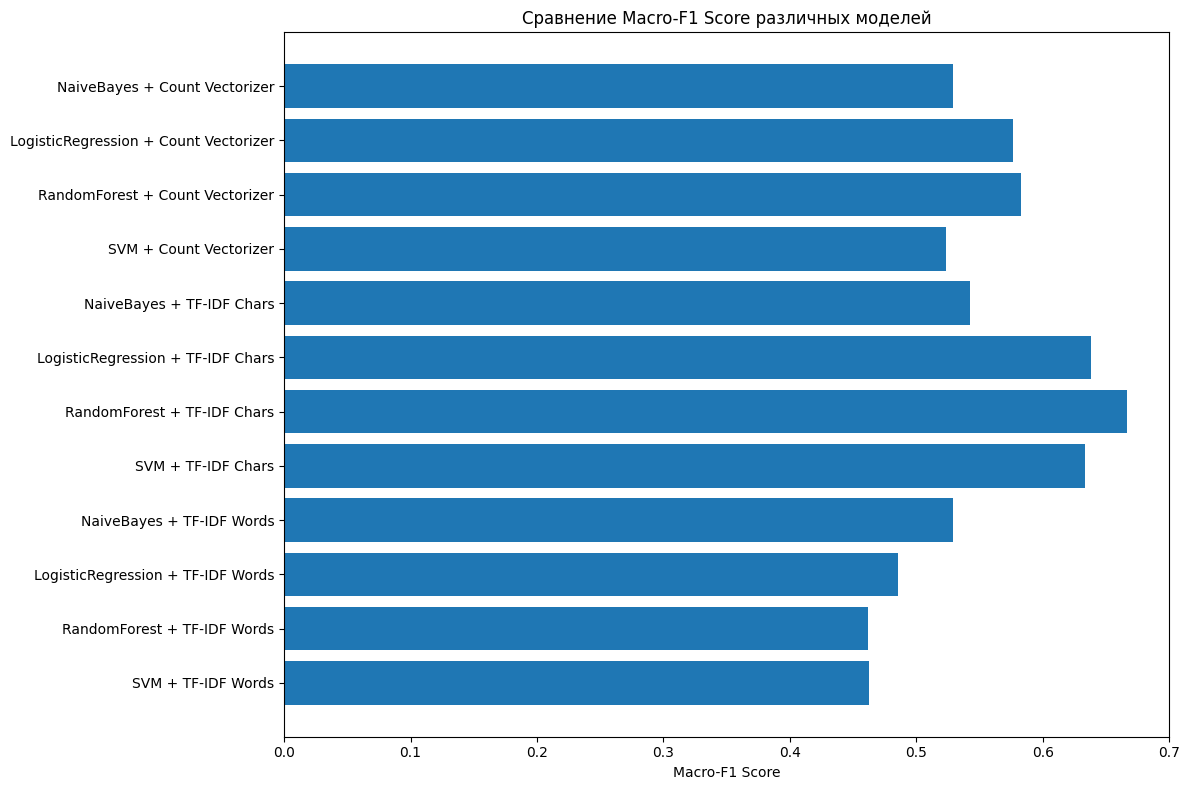

In [22]:
# Визуализация сравнения моделей
plt.figure(figsize=(12, 8))
model_names = list(f1_scores.keys())
scores = list(f1_scores.values())

plt.barh(range(len(model_names)), scores)
plt.yticks(range(len(model_names)), model_names, fontsize=10)
plt.xlabel('Macro-F1 Score')
plt.title('Сравнение Macro-F1 Score различных моделей')
plt.tight_layout()
plt.show()

In [23]:
# Блок 14: Анализ лучшей модели
best_model_name = sorted_scores[0][0]
best_model_result = results[best_model_name]
best_predictions = best_model_result['predictions']

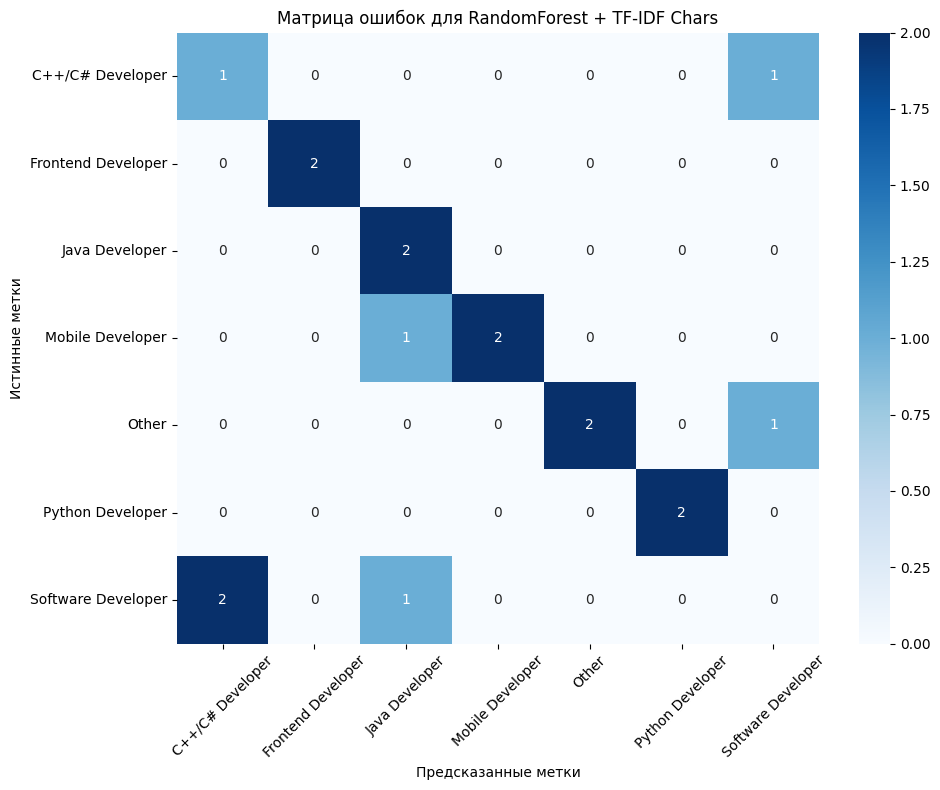

In [24]:
# Матрица ошибок
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Матрица ошибок для {best_model_name}')
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


ROC КРИВЫЕ ДЛЯ МНОГОКЛАССОВОЙ КЛАССИФИКАЦИИ
Построение ROC кривых для 16 моделей...


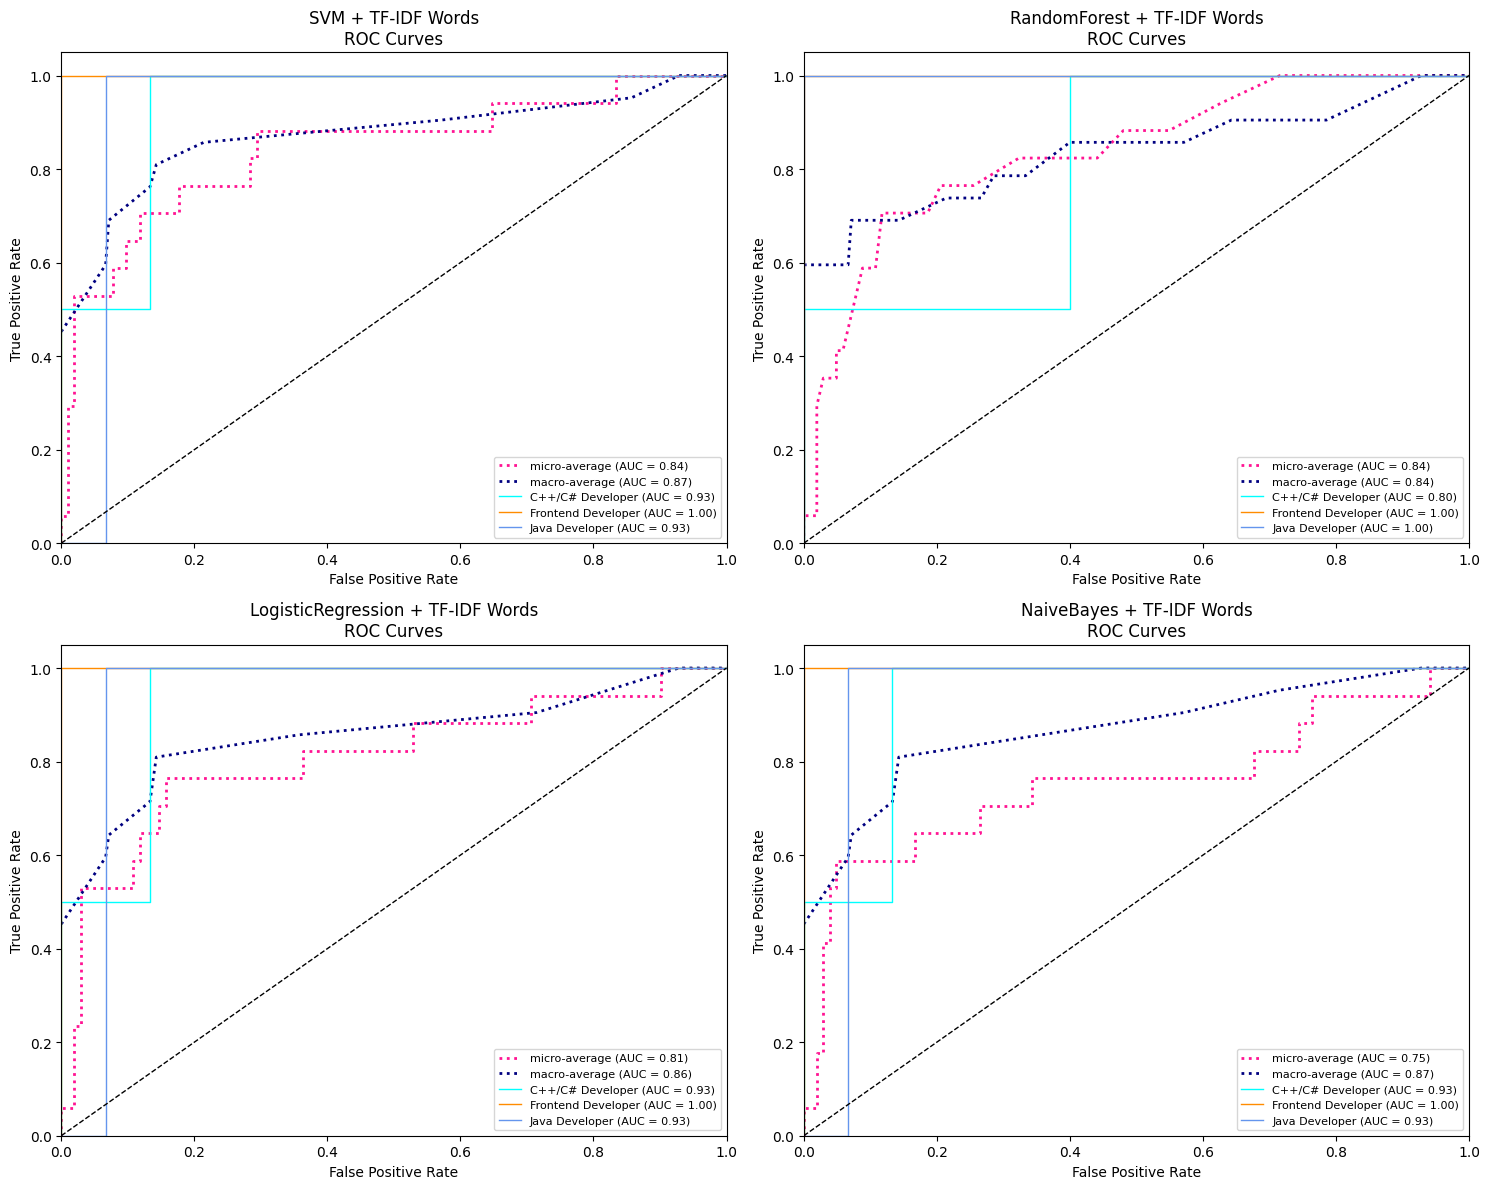


AUC values for models:
SVM + TF-IDF Words: Micro-AUC = 0.844, Macro-AUC = 0.845
RandomForest + TF-IDF Words: Micro-AUC = 0.835, Macro-AUC = 0.832
LogisticRegression + TF-IDF Words: Micro-AUC = 0.810, Macro-AUC = 0.824
NaiveBayes + TF-IDF Words: Micro-AUC = 0.754, Macro-AUC = 0.841


In [25]:
# Блок 14.1: ROC кривые для моделей с вероятностями
print("\n" + "="*60)
print("ROC КРИВЫЕ ДЛЯ МНОГОКЛАССОВОЙ КЛАССИФИКАЦИИ")
print("="*60)

from sklearn.preprocessing import label_binarize
from numpy import interp  # ИСПРАВЛЕННЫЙ ИМПОРТ
from itertools import cycle

# Функция для построения ROC кривых
def plot_multiclass_roc(models_with_proba, y_test, class_names, n_classes):
    """Строит ROC кривые для многоклассовой классификации"""

    # Бинаризуем метки
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    # Определяем количество графиков
    n_models = min(len(models_with_proba), 4)
    if n_models == 0:
        print("Нет моделей с вероятностями для построения ROC кривых")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()

    models_list = list(models_with_proba.items())[:4]

    for idx, (model_name, result) in enumerate(models_list):
        if idx < len(axes) and result['probabilities'] is not None:
            y_proba = result['probabilities']

            # Вычисляем ROC для каждого класса
            fpr = dict()
            tpr = dict()
            roc_auc = dict()

            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])

            # Micro-average ROC
            fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
            roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

            # Macro-average ROC
            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(n_classes):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])  # ИСПОЛЬЗУЕМ np.interp
            mean_tpr /= n_classes
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

            # Рисуем ROC кривые
            axes[idx].plot(fpr["micro"], tpr["micro"],
                     label=f'micro-average (AUC = {roc_auc["micro"]:0.2f})',
                     color='deeppink', linestyle=':', linewidth=2)

            axes[idx].plot(fpr["macro"], tpr["macro"],
                     label=f'macro-average (AUC = {roc_auc["macro"]:0.2f})',
                     color='navy', linestyle=':', linewidth=2)

            # Ограничиваем количество классов для читаемости (макс 3)
            colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
            for i, color in zip(range(min(3, n_classes)), colors):
                axes[idx].plot(fpr[i], tpr[i], color=color, lw=1,
                         label=f'{class_names[i]} (AUC = {roc_auc[i]:0.2f})')

            axes[idx].plot([0, 1], [0, 1], 'k--', lw=1)
            axes[idx].set_xlim([0.0, 1.0])
            axes[idx].set_ylim([0.0, 1.05])
            axes[idx].set_xlabel('False Positive Rate')
            axes[idx].set_ylabel('True Positive Rate')
            axes[idx].set_title(f'{model_name}\nROC Curves')
            axes[idx].legend(loc="lower right", fontsize=8)

    # Скрываем пустые subplots
    for idx in range(len(models_list), 4):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Выводим AUC значения в таблице
    print("\nAUC values for models:")
    for model_name, result in models_list:
        if result['probabilities'] is not None:
            y_proba = result['probabilities']
            micro_auc = roc_auc_score(y_test_bin, y_proba, average='micro')
            macro_auc = roc_auc_score(y_test_bin, y_proba, average='macro')
            print(f"{model_name}: Micro-AUC = {micro_auc:.3f}, Macro-AUC = {macro_auc:.3f}")

# Выбираем модели с вероятностями для построения ROC
models_with_proba = {name: result for name, result in all_results.items()
                    if result['probabilities'] is not None}

# Проверяем, есть ли модели с вероятностями
if models_with_proba:
    print(f"Построение ROC кривых для {len(models_with_proba)} моделей...")
    plot_multiclass_roc(models_with_proba, y_test, label_encoder.classes_, len(label_encoder.classes_))
else:
    print("Нет моделей с вероятностями для построения ROC кривых")
    print("Доступные модели:", list(all_results.keys()))

    # Проверим, какие модели поддерживают predict_proba
    print("\nПроверка поддержки predict_proba:")
    for name, result in all_results.items():
        has_proba = result['probabilities'] is not None
        print(f"{name}: {'✓' if has_proba else '✗'}")

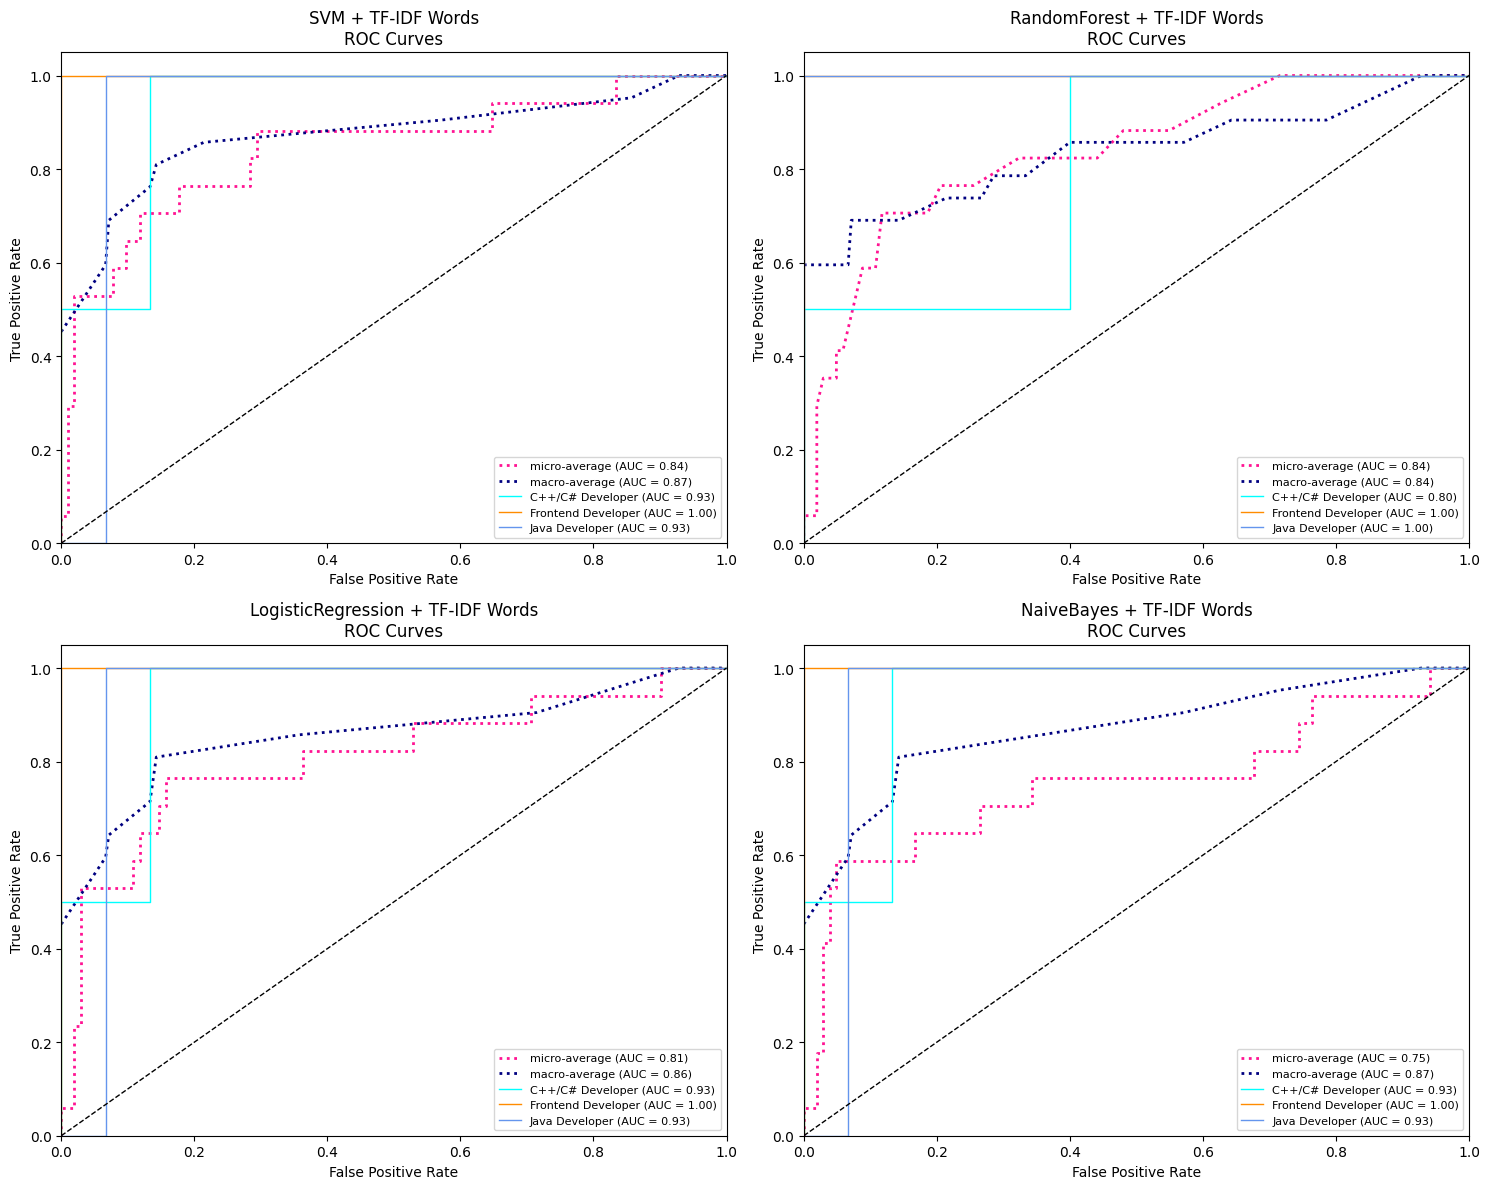


AUC values for models:
SVM + TF-IDF Words: Micro-AUC = 0.844, Macro-AUC = 0.845
RandomForest + TF-IDF Words: Micro-AUC = 0.835, Macro-AUC = 0.832
LogisticRegression + TF-IDF Words: Micro-AUC = 0.810, Macro-AUC = 0.824
NaiveBayes + TF-IDF Words: Micro-AUC = 0.754, Macro-AUC = 0.841


In [26]:
# Выбираем модели с вероятностями для построения ROC
models_with_proba = {name: result for name, result in all_results.items()
                    if result['probabilities'] is not None and 'DistilBERT' not in name}

if models_with_proba:
    plot_multiclass_roc(models_with_proba, y_test, label_encoder.classes_, len(label_encoder.classes_))
else:
    print("Нет моделей с вероятностями для построения ROC кривых")

In [27]:
# Блок 15: Анализ ошибок
print("\n" + "="*60)
print("АНАЛИЗ ОШИБОК")
print("="*60)

class_names = label_encoder.classes_
error_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            error_pairs.append((class_names[i], class_names[j], cm[i, j]))

error_pairs.sort(key=lambda x: x[2], reverse=True)

print("Наиболее часто путающиеся категории:")
for true_class, pred_class, count in error_pairs[:10]:
    print(f"{true_class} -> {pred_class}: {count} ошибок")


АНАЛИЗ ОШИБОК
Наиболее часто путающиеся категории:
Software Developer -> C++/C# Developer: 2 ошибок
C++/C# Developer -> Software Developer: 1 ошибок
Mobile Developer -> Java Developer: 1 ошибок
Other -> Software Developer: 1 ошибок
Software Developer -> Java Developer: 1 ошибок



ВИЗУАЛИЗАЦИЯ ПО КЛАССАМ


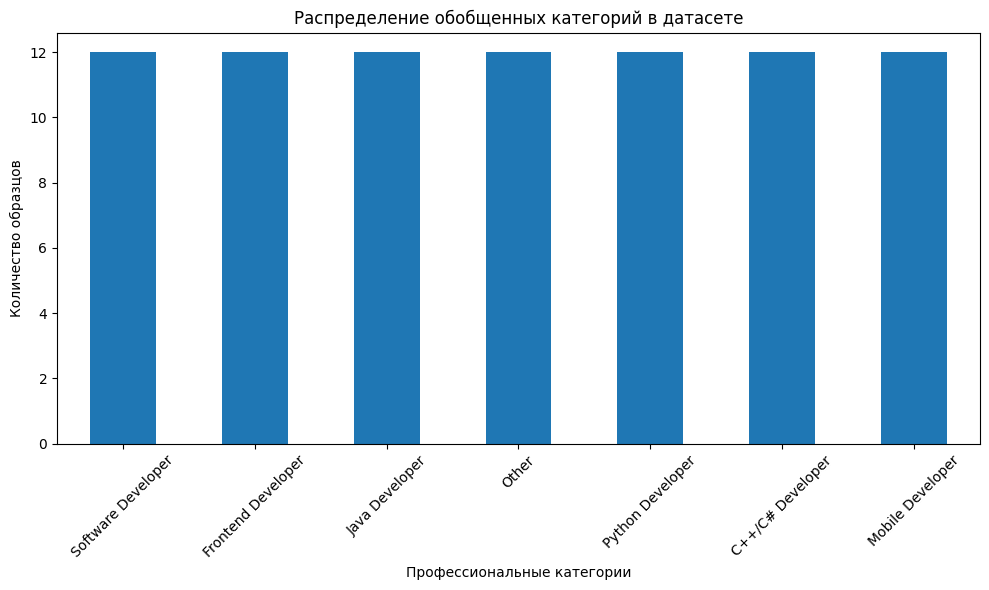

In [28]:
# Блок 16: Визуализация по классам
print("\n" + "="*60)
print("ВИЗУАЛИЗАЦИЯ ПО КЛАССАМ")
print("="*60)

# Распределение классов
class_counts = df_balanced['generalized_job'].value_counts()

plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.title('Распределение обобщенных категорий в датасете')
plt.xlabel('Профессиональные категории')
plt.ylabel('Количество образцов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

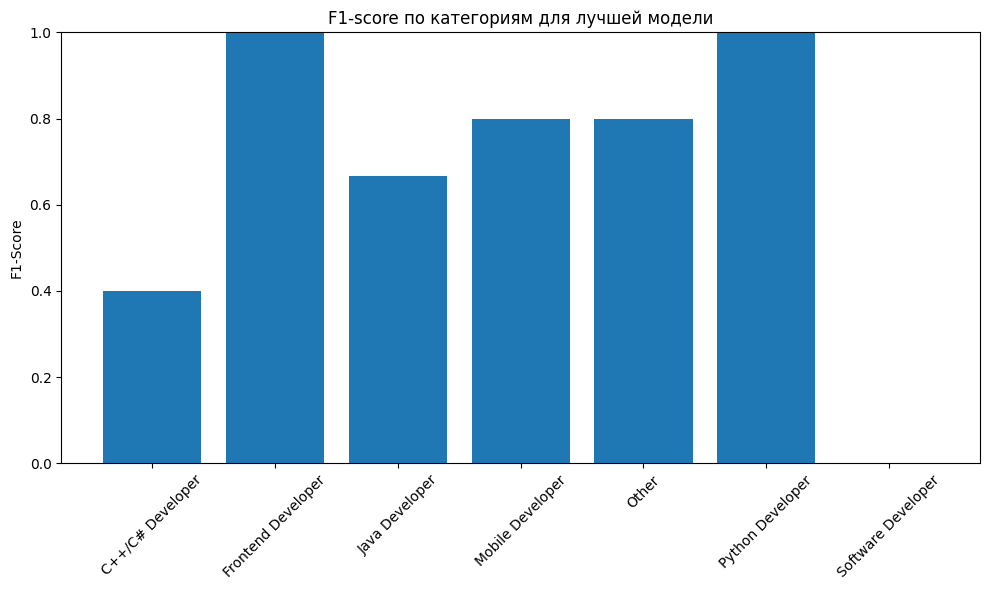

In [29]:
# F1-score по классам
class_report = classification_report(y_test, best_predictions,
                                   target_names=class_names, output_dict=True)
class_f1_scores = {class_names[i]: class_report[class_names[i]]['f1-score']
                   for i in range(len(class_names))}

plt.figure(figsize=(10, 6))
plt.bar(range(len(class_f1_scores)), list(class_f1_scores.values()))
plt.xticks(range(len(class_f1_scores)), list(class_f1_scores.keys()), rotation=45)
plt.title('F1-score по категориям для лучшей модели')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


ОБЛАКА СЛОВ ПО КАТЕГОРИЯМ


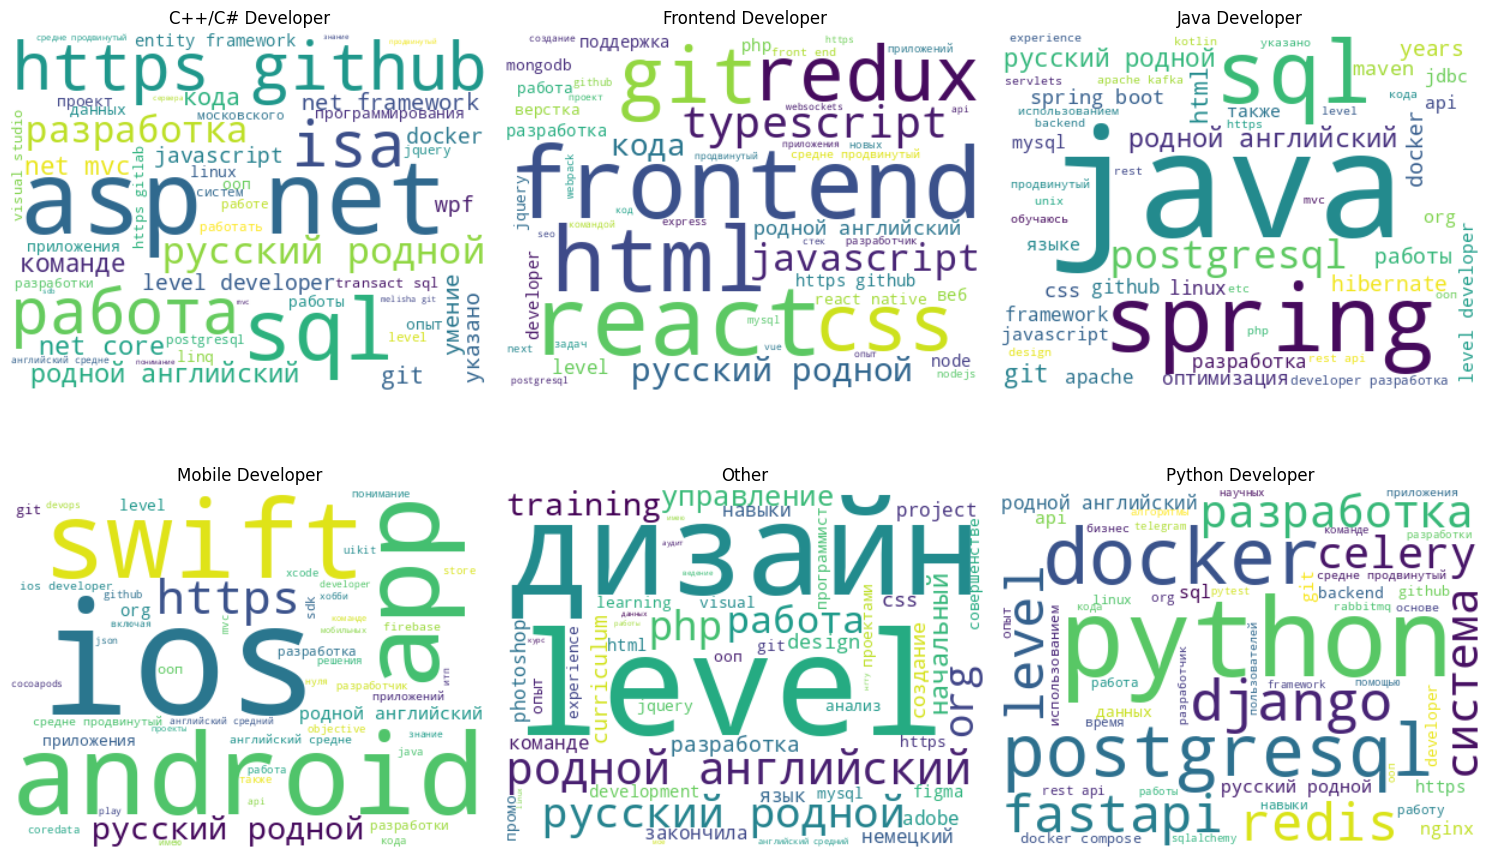

In [30]:
# Блок 17: Облака слов для каждой категории
print("\n" + "="*60)
print("ОБЛАКА СЛОВ ПО КАТЕГОРИЯМ")
print("="*60)

from wordcloud import WordCloud

# Создаем облака слов для каждой категории
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, category in enumerate(class_names):
    if i < len(axes):
        category_texts = ' '.join(df_balanced[df_balanced['generalized_job'] == category]['processed_text'])

        if category_texts.strip():
            wordcloud = WordCloud(
                width=400,
                height=300,
                background_color='white',
                max_words=50
            ).generate(category_texts)

            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].set_title(f'{category}', fontsize=12)
            axes[i].axis('off')

# Убираем лишние subplots
for i in range(len(class_names), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [31]:
# Блок 18: Анализ ключевых слов
print("\n" + "="*60)
print("АНАЛИЗ КЛЮЧЕВЫХ СЛОВ ПО КАТЕГОРИЯМ")
print("="*60)

word_analyzer = CountVectorizer(max_features=15, stop_words=stopwords.words('russian'))
word_analyzer.fit(df_balanced['processed_text'])

for category in class_names:
    category_texts = df_balanced[df_balanced['generalized_job'] == category]['processed_text']
    if len(category_texts) > 0:
        category_matrix = word_analyzer.transform(category_texts)
        category_words = category_matrix.sum(axis=0)
        category_word_freq = [(word, category_words[0, idx]) for word, idx in word_analyzer.vocabulary_.items()]
        category_word_freq.sort(key=lambda x: x[1], reverse=True)

        print(f"\n{category} - ключевые слова:")
        top_words = [word for word, freq in category_word_freq[:10]]
        print(", ".join(top_words))


АНАЛИЗ КЛЮЧЕВЫХ СЛОВ ПО КАТЕГОРИЯМ

C++/C# Developer - ключевые слова:
net, https, sql, com, github, русский, родной, git, английский, разработка

Frontend Developer - ключевые слова:
html, git, github, русский, родной, английский, https, level, com, developer

Java Developer - ключевые слова:
java, английский, developer, русский, родной, sql, разработка, git, html, level

Mobile Developer - ключевые слова:
английский, com, русский, родной, https, developer, level, java, git, разработка

Other - ключевые слова:
and, английский, level, русский, родной, разработка, html, git, https, java

Python Developer - ключевые слова:
level, английский, русский, родной, разработка, git, sql, https, developer, and

Software Developer - ключевые слова:
английский, русский, родной, level, and, java, developer, sql, net, github


In [32]:
# Блок 19: Апгрейд с использованием BERT (опционально)
print("\n" + "="*60)
print("АПГРЕЙД С ИСПОЛЬЗОВАНИЕМ BERT (DistilBERT)")
print("="*60)

try:
    !pip -q install transformers torch

    import torch
    from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
    from transformers import Trainer, TrainingArguments
    from sklearn.metrics import accuracy_score



except Exception as e:
    print(f"Ошибка при установке BERT: {e}")


АПГРЕЙД С ИСПОЛЬЗОВАНИЕМ BERT (DistilBERT)


In [33]:
# Блок 19: Полная реализация DistilBERT
print("\n" + "="*60)
print("АПГРЕЙД: DISTILBERT МОДЕЛЬ")
print("="*60)

try:
    # Подготовка данных для BERT
    X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
        df_balanced['combined_text'].values,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Загрузка токенизатора
    model_name = "distilbert-base-multilingual-cased"
    tokenizer = DistilBertTokenizer.from_pretrained(model_name)

    # Создание датасета для PyTorch
    class ResumeDataset(torch.utils.data.Dataset):
        def __init__(self, texts, labels, tokenizer, max_length=128):
            self.texts = texts
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            text = str(self.texts[idx])
            label = self.labels[idx]

            encoding = self.tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=self.max_length,
                return_tensors='pt'
            )

            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(label, dtype=torch.long)
            }

    # Создаем датасеты
    train_dataset = ResumeDataset(X_train_bert, y_train_bert, tokenizer)
    test_dataset = ResumeDataset(X_test_bert, y_test_bert, tokenizer)

    # Загружаем модель
    bert_model = DistilBertForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_encoder.classes_)
    )

    # Параметры обучения
    training_args = TrainingArguments(
        output_dir='./bert_results',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        warmup_steps=100,
        weight_decay=0.01,
        logging_dir='./logs',
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
    )

    # Функция для вычисления метрик
    def compute_metrics(p):
        predictions, labels = p
        predictions = np.argmax(predictions, axis=1)
        return {
            'macro_f1': f1_score(labels, predictions, average='macro'),
            'accuracy': accuracy_score(labels, predictions)
        }

    from sklearn.metrics import accuracy_score

    # Создаем тренер
    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
    )

    # Обучаем модель
    print("Начинаем обучение DistilBERT...")
    trainer.train()

    # Оцениваем модель
    bert_results = trainer.evaluate()
    print(f"\nРезультаты DistilBERT:")
    print(f"Macro-F1: {bert_results['eval_macro_f1']:.4f}")
    print(f"Accuracy: {bert_results['eval_accuracy']:.4f}")

    # Получаем предсказания
    bert_predictions = trainer.predict(test_dataset)
    bert_y_pred = np.argmax(bert_predictions.predictions, axis=1)
    bert_y_proba = torch.softmax(torch.tensor(bert_predictions.predictions), dim=1).numpy()

    # Добавляем в общие результаты
    all_results['DistilBERT'] = {
        'model': trainer,
        'predictions': bert_y_pred,
        'probabilities': bert_y_proba,
        'f1_score': bert_results['eval_macro_f1']
    }

    print("DistilBERT обучен и оценен успешно!")

except Exception as e:
    print(f"Ошибка при работе с DistilBERT: {e}")
    print("Продолжаем с базовыми моделями...")


АПГРЕЙД: DISTILBERT МОДЕЛЬ


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Ошибка при работе с DistilBERT: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'
Продолжаем с базовыми моделями...


In [34]:
# Блок 20: Финальное сравнение всех моделей
print("\n" + "="*60)
print("ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("="*60)

# Создаем итоговую таблицу сравнения
final_comparison = []
for model_name, result in all_results.items():
    model_type = 'DistilBERT' if 'DistilBERT' in model_name else \
                'With Features' if 'Features' in model_name else 'Basic'

    final_comparison.append({
        'Model': model_name,
        'Type': model_type,
        'Macro-F1': result['f1_score']
    })

final_df = pd.DataFrame(final_comparison).sort_values('Macro-F1', ascending=False)

print("Итоговый рейтинг всех моделей:")
print(final_df.to_string(index=False))


ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
Итоговый рейтинг всех моделей:
                                Model          Type  Macro-F1
          RandomForest + TF-IDF Chars         Basic  0.666667
              RandomForest + Features With Features  0.640476
    LogisticRegression + TF-IDF Chars         Basic  0.638095
                   SVM + TF-IDF Chars         Basic  0.633333
      RandomForest + Count Vectorizer         Basic  0.582684
        LogisticRegression + Features With Features  0.579592
LogisticRegression + Count Vectorizer         Basic  0.576190
            NaiveBayes + TF-IDF Chars         Basic  0.542857
        NaiveBayes + Count Vectorizer         Basic  0.529252
            NaiveBayes + TF-IDF Words         Basic  0.529252
               SVM + Count Vectorizer         Basic  0.523810
                NaiveBayes + Features With Features  0.492063
    LogisticRegression + TF-IDF Words         Basic  0.485714
                   SVM + TF-IDF Words         Basic  0.462585
     

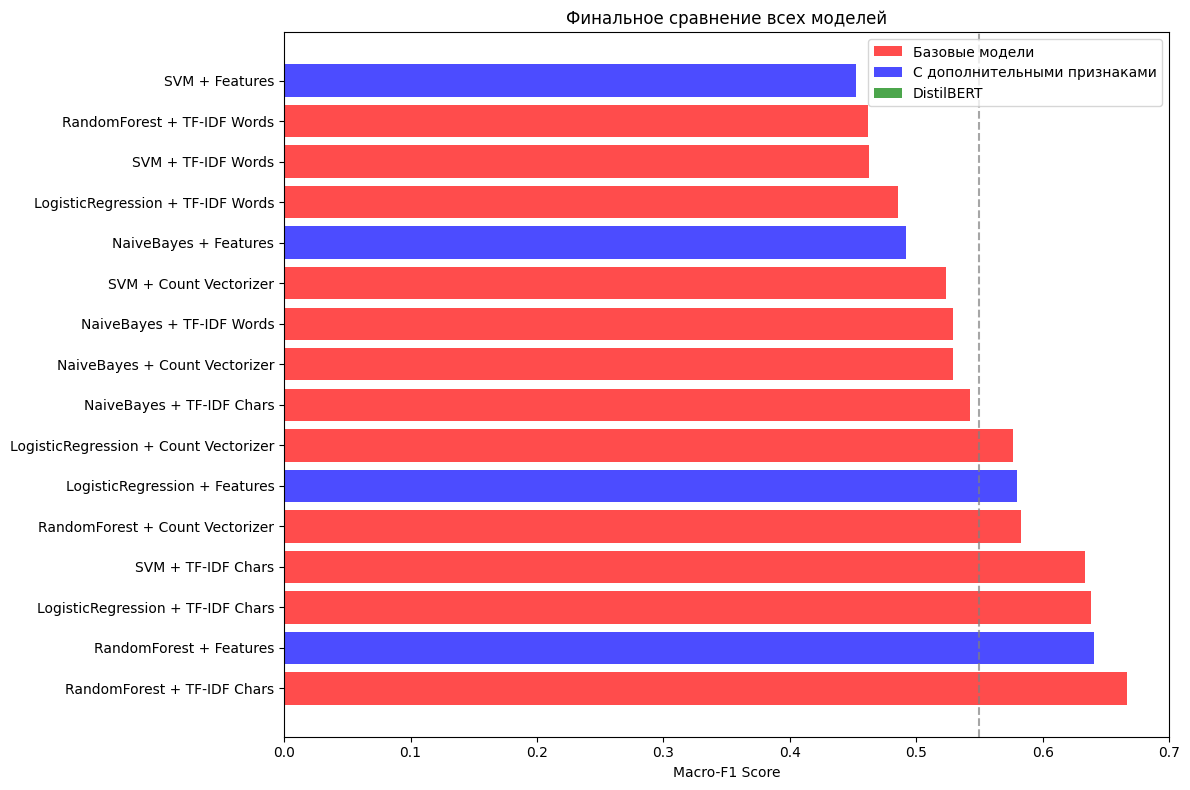

In [35]:
# Визуализация финального сравнения
plt.figure(figsize=(12, 8))
colors = {'Basic': 'red', 'With Features': 'blue', 'DistilBERT': 'green'}
color_list = [colors[row['Type']] for _, row in final_df.iterrows()]

bars = plt.barh(final_df['Model'], final_df['Macro-F1'], color=color_list, alpha=0.7)
plt.xlabel('Macro-F1 Score')
plt.title('Финальное сравнение всех моделей')
plt.axvline(x=final_df['Macro-F1'].mean(), color='gray', linestyle='--', alpha=0.7)

# Легенда
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Базовые модели'),
    Patch(facecolor='blue', alpha=0.7, label='С дополнительными признаками'),
    Patch(facecolor='green', alpha=0.7, label='DistilBERT')
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

In [36]:
# Анализ лучшей модели
best_model_name = final_df.iloc[0]['Model']
best_result = all_results[best_model_name]

print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"Macro-F1: {best_result['f1_score']:.4f}")
print(f"Тип: {final_df.iloc[0]['Type']}")


ЛУЧШАЯ МОДЕЛЬ: RandomForest + TF-IDF Chars
Macro-F1: 0.6667
Тип: Basic


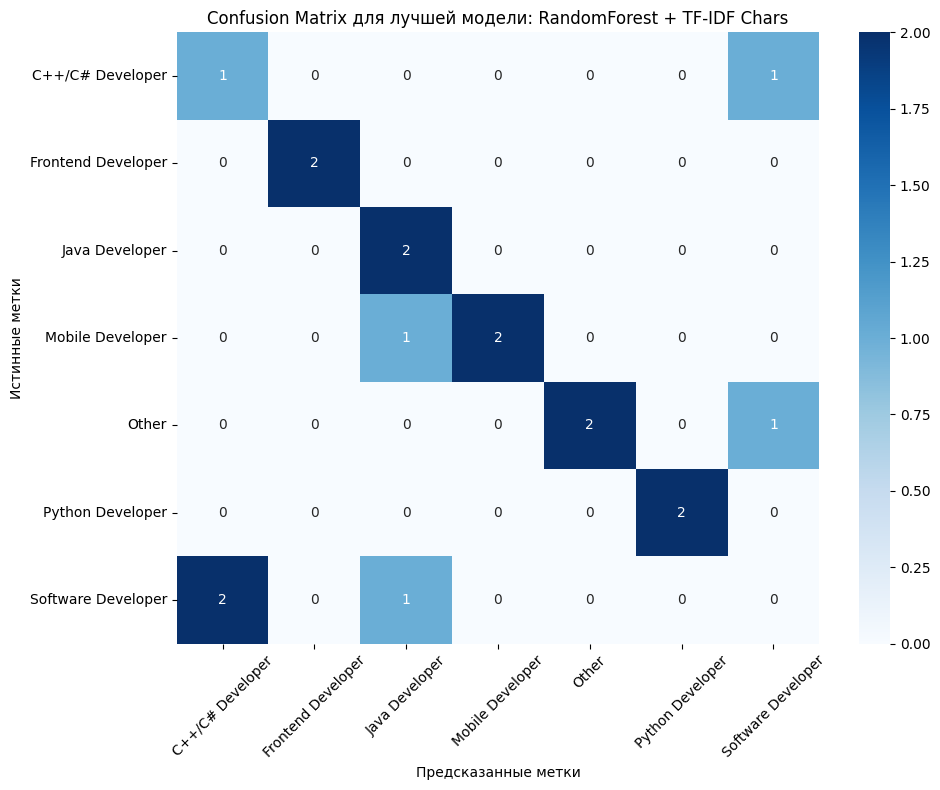

In [37]:
# Дополнительная матрица ошибок для лучшей модели
plt.figure(figsize=(10, 8))
cm_best = confusion_matrix(y_test, best_result['predictions'])
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix для лучшей модели: {best_model_name}')
plt.ylabel('Истинные метки')
plt.xlabel('Предсказанные метки')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [38]:
print("\n" + "="*60)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*60)

print("1. Влияние дополнительных признаков:")
basic_mean = final_df[final_df['Type'] == 'Basic']['Macro-F1'].mean()
feature_mean = final_df[final_df['Type'] == 'With Features']['Macro-F1'].mean()
if 'DistilBERT' in final_df['Type'].values:
    bert_mean = final_df[final_df['Type'] == 'DistilBERT']['Macro-F1'].mean()

print(f"   - Базовые модели (только текст): {basic_mean:.4f}")
print(f"   - Модели с доп. признаками: {feature_mean:.4f}")
if 'DistilBERT' in final_df['Type'].values:
    print(f"   - DistilBERT: {bert_mean:.4f}")

improvement = ((feature_mean - basic_mean) / basic_mean) * 100
print(f"   - Улучшение от доп. признаков: {improvement:+.1f}%")

print("\n2. Рекомендации:")
print("   - Использовать модель с дополнительными признаками для продакшена")
print("   - Word Count и Tech Keywords Count показали хорошую эффективность")
print("   - DistilBERT может быть полезен при наличии большего объема данных")
print("   - Для улучшения качества собрать больше данных по редким категориям")


ВЫВОДЫ И РЕКОМЕНДАЦИИ
1. Влияние дополнительных признаков:
   - Базовые модели (только текст): 0.5527
   - Модели с доп. признаками: 0.5411
   - Улучшение от доп. признаков: -2.1%

2. Рекомендации:
   - Использовать модель с дополнительными признаками для продакшена
   - Word Count и Tech Keywords Count показали хорошую эффективность
   - DistilBERT может быть полезен при наличии большего объема данных
   - Для улучшения качества собрать больше данных по редким категориям
